In [1]:
# jax ecosystem
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", False)

device = jax.local_devices()[0]
print(device.device_kind)

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import dorito
import amigo
import dLux
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os
import sys

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
# plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

def get_cmap(cmap_name: str):
    cmap = mpl.colormaps[cmap_name]
    cmap.set_bad("k", 0.5)
    return cmap

inferno = get_cmap("inferno")
seismic = get_cmap("seismic")
coolwarm = get_cmap("coolwarm")

if jax.config.read("jax_enable_x64"):
    print("64bit enabled")
else:
    print("32bit enabled")

import equinox
import lineax

print("jax version:", jax.__version__)
print("equinox version:", equinox.__version__)
print("lineax version", lineax.__version__)
print("zodiax version:", zodiax.__version__)
print("dLux version:", dLux.__version__)
print("amigo version:", amigo.__version__)
print("dorito version:", dorito.__version__)

NVIDIA H200
64bit enabled
jax version: 0.8.3
equinox version: 0.13.7
lineax version 0.1.0
zodiax version: 0.5.0
dLux version: 0.15.0
amigo version: 0.0.10
dorito version: 0.2.0


# Loading in data

In [2]:
# Setting data path
from socket import gethostname
from retrain_fns import Tee

print(f"host name: {gethostname()}")

# compile caching
if device.device_kind != "cpu":
    if gethostname().startswith("max-"):
        jax.config.update("jax_compilation_cache_dir", "/tmp/jax_cache")
    else:
        jax.config.update("jax_compilation_cache_dir", "/fred/oz440/max/jax_cache")

    jax.config.update("jax_persistent_cache_min_entry_size_bytes", -1)
    jax.config.update("jax_persistent_cache_min_compile_time_secs", 0)
    jax.config.update("jax_persistent_cache_enable_xla_caches", "xla_gpu_per_fusion_autotune_cache_dir")

    stats = device.memory_stats()
    free = stats["bytes_limit"] - stats["bytes_in_use"]
    print(f"Total VRAM : {stats['bytes_limit'] / 1024**3:.2f} GB")
    print(f"In use     : {stats['bytes_in_use'] / 1024**3:.2f} GB")
    print(f"Free       : {free / 1024**3:.2f} GB")


if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/research-data/PRJ-PAT/max/data/JWST/"
    cache_dir = "/Volumes/research-data/PRJ-PAT/max/data/amigo_cache"
    amigo_files_path = "/Volumes/research-data/PRJ-PAT/max/data/amigo_files/v_0.0.11"
    output_path = "/Users/mc/nt_outputs/local_retrain"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.11"
    output_path = "/home/dgxuser/max/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.11"
    output_path = "/fred/oz440/max/outputs/retrain"

# cleaning directory of empty folders
for d in os.listdir(output_path):
    this_dir = os.path.join(output_path, d)
    fs = os.listdir(this_dir)
    if len(fs) == 0:
        os.rmdir(this_dir)

# dealing with saving figures when running in script
def check_script():
    if "__file__" in globals():
        print("Running as a script")
        return True
    else:
        print("Running in a notebook or interactive shell")
        return False

# Quick toggle flags
epochs = 10000
# intermediate_prints = []
intermediate_prints = [100, 5000]
# intermediate_prints = [10, 100, 1000, 1050, 2000]
# intermediate_prints = list(range(1000, 19000, 2000))
n_files_per_filt = 1
n_vals_per_filt = 1
one_filt_flag = False
binary_flag = False
val_flag = False
flat_flag = False
flat_only = False
static_optics = False
plot_flag = check_script()
plot_flag = True
save_flag = check_script()
recalculate_flag = False


if save_flag:
    try:
        job_index = int(sys.argv[1])
    except:
        pass
    
    job_id = os.environ.get("SLURM_ARRAY_JOB_ID")
    task_id = os.environ.get("SLURM_ARRAY_TASK_ID")
    if job_id is not None and task_id is not None:
        job_id = f"{job_id}_{task_id}"
    elif job_id is None:
        from datetime import datetime
        form = "%y-%m-%d_%H-%M-%S_%f"
        now = datetime.now()
        job_id = now.strftime(form)

    job_name = os.environ.get("SLURM_JOB_NAME")
    if job_name is not None:
        job_id = "_".join([job_id, job_name])
    
    print(f"Job ID: {job_id}")
    save_path = os.path.join(output_path, job_id)
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    import shutil

    shutil.copy(__file__, save_path + "/script.py")

    log_path = os.path.join(save_path, "output.txt")

    sys.stdout = Tee(log_path)
    sys.stderr = sys.stdout  # capture errors too

else:
    save_path = None


print(f"Save path: {save_path}")
print(f"amigo_files_path: {amigo_files_path}")

host name: max-imagev2-0-102
Total VRAM : 104.79 GB
In use     : 0.00 GB
Free       : 104.79 GB
Running in a notebook or interactive shell
Running in a notebook or interactive shell
Save path: None
amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.11


In [3]:
from retrain_fns import summarise_files
import importlib

resource_path = importlib.resources.files(amigo).joinpath("data/badpix.npy")

with importlib.resources.as_file(resource_path) as file_path:
    badpix = np.array(np.load(file_path), dtype=int)

# # Add extra bad pixels
# badpix = np.load(f"{cache_dir}/full_badpix.npy")
# # badpix = np.load(f"{cache_dir}/full_badpix.npy")
# badpix = np.array(badpix, dtype=int)

def add_badpix(file):
    file["BADPIX"].data = badpix
    if file[0].header["EXP_TYPE"] == "NIS_DARK":
        file["BADPIX"].data[25, 74] = 1
    return file


## Validation files
Calibrators from other science programs

In [4]:
def sort_files(files, n):
    files.sort(key=lambda x: (x[0].header["PROGRAM"], x[0].header["FILTER"], x[0].header["PATT_NUM"]), reverse=True)
    filts = ["F480M", "F430M", "F380M"]
    these_files = {}
    for filt in filts:
        x = []
        for file in files:
            if file[0].header["FILTER"] == filt:
                if one_filt_flag and filt != "F480M":
                    continue
                x.append(file)
        these_files[filt] = x[0:n]
    files = [f for sub_f in these_files.values() for f in sub_f]
    return files

In [5]:
# LOADING IN DATA
from astropy.io import fits
from amigo.files import get_files

val_files = []

# Collated validator subset
program_path = os.path.join(data_dir, "VAL_SUBSET/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
files = sort_files(files, n_vals_per_filt)
val_files += files

# Adding bad pixels and summarising metadata
val_files = [add_badpix(file) for file in val_files]
summarise_files(val_files)

  program     target filter dither     g/i        date              PI   CAL
0    1843  HD-205827  F480M    1/1  10/641  26-10-2022  Kammerer, Jens  True
1    1843  HD-205827  F380M    1/1  3/7800  26-10-2022  Kammerer, Jens  True
2    1843  HD-205827  F430M    1/1  7/1885  26-10-2022  Kammerer, Jens  True


## Calibration files
The main training data, including flats.

In [6]:
calpsf_files = []
calbin_files = []

print("CAL4481 - Anand Sivaramakrishnan")
program_path = os.path.join(data_dir, "4481/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
calpsf_files += files
calpsf_files = [add_badpix(file) for file in calpsf_files]
calpsf_files = sort_files(calpsf_files, n_files_per_filt)
summarise_files(calpsf_files)

print()
print("CAL8330 - Benjamin Pope")
program_path = os.path.join(data_dir, "8330/calslope/")
files = get_files(program_path, "nis_calslope")
calbin_files += files
calbin_files = [file for file in calbin_files if file[0].header["NGROUPS"] > 3]
calbin_files = [add_badpix(file) for file in calbin_files[0:15]]
calbin_files = sort_files(calbin_files, n_files_per_filt)
summarise_files(calbin_files)

CAL4481 - Anand Sivaramakrishnan
  program    target filter dither      g/i        date                       PI   CAL
0    4481  HD-41094  F480M    5/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
1    4481  HD-41094  F380M    5/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
2    4481  HD-41094  F430M    5/5   20/905  05-05-2024  Sivaramakrishnan, Anand  True

CAL8330 - Benjamin Pope
  program    target filter dither     g/i        date              PI    CAL
0    8330  V-EZ-Aqr  F480M  10/10  18/220  11-11-2025  Pope, Benjamin  False
1    8330  V-EZ-Aqr  F380M   9/10  11/260  11-11-2025  Pope, Benjamin  False
2    8330  V-EZ-Aqr  F430M   9/10  16/250  11-11-2025  Pope, Benjamin  False


Flats.

In [7]:
flat_files = []
print()
print("FLATS")
program_path = os.path.join(data_dir, "FLATS/calslope/")
files = get_files(program_path, "nis_calslope", EXP_TYPE="NIS_LAMP")
flat_files += files
# flat_files = [file for file in flat_files if file[0].header["NGROUPS"] != 45]
flat_files = sort_files(flat_files, n_files_per_filt)

flat_files = [add_badpix(file) for file in flat_files]
summarise_files(flat_files)


FLATS
  program   target filter dither    g/i        date             PI   CAL
0    1503  UNKNOWN  F380M    1/1  30/10  04-02-2023  Martel, Andre  FLAT
1    1503  UNKNOWN  F480M    1/1  30/10  16-03-2023  Martel, Andre  FLAT


# Exposures

In [8]:
from amigo.model_fits import PointFit

class UniqueAbPointFit(PointFit):
    def get_key(self, param):
        match param:
            case "aberrations":
                return "_".join((self.filter, self.key))

        return super().get_key(param)

In [9]:
from amigo.model_fits import PointFit, FlatFit
from retrain_fns import BinaryFit, DarkFit

# Construct the exposures
calpsf_exposures = [PointFit(file) for file in calpsf_files]
calbin_exposures = [BinaryFit(file) for file in calbin_files]
val_exposures = [UniqueAbPointFit(file) for file in val_files]
flat_exposures = [FlatFit(file) for file in flat_files]
# dark_exposures = [DarkFit(file) for file in dark_files]

if binary_flag:
    cal_exposures = calpsf_exposures + calbin_exposures
else:
    cal_exposures = [*calpsf_exposures]

exposures = [*cal_exposures]
if val_flag:
    exposures += val_exposures
if flat_flag:
    exposures += flat_exposures
if flat_only:
    exposures = [*flat_exposures]

print(f"Total number of exposures: {len(exposures)}")

# just closing the files
files = calpsf_files + calbin_files + val_files + flat_files# + dark_files
_ = [f.close() for f in files]

Total number of exposures: 3


Finally, let's batch the exposures for training.

In [10]:
from amigo.fitting import batch_exposures

bs = 3
# bs = 1 if one_filt_flag else 3

# Get the batches: Calibrator, flats, and validators
cal_batch = batch_exposures(cal_exposures, batch_size=bs, key="cal")
flat_batch = batch_exposures(flat_exposures, batch_size=bs, key="flat")
val_batch = batch_exposures(val_exposures, batch_size=bs, key="val")
# dark_batch = batch_exposures(dark_exposures, batch_size=bs, key="dark")
nn_batches = {**cal_batch, **flat_batch}

# Building model

In [11]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import LinearDetector
from amigo.ramp_models import NonLinearRamp
from amigo.read_models import ReadModel
from retrain_fns import nn_setup_options

nn_arch = nn_setup_options[2]
# nn_arch = nn_setup_options[job_index]


load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

optics = AMIOptics(static=static_optics)

# Get the model
model = AmigoModel(
    exposures=exposures,
    # optics=AMIOptics(),
    optics=optics,
    detector=LinearDetector(),
    ramp_model=NonLinearRamp(**nn_arch),
    read=ReadModel(),
    # state=load_dict(amigo_files_path + "/calibration.npy"),
)
print(nn_arch, model.nn_weights.shape)

{'hidden_width': 12, 'n_hidden_layers': 3} (5616,)


Populate from state.

In [12]:
state = load_dict(amigo_files_path + "/calibration.npy")
# best_state = load_dict(amigo_files_path + "/best_state06.npy")
best_state = load_dict(amigo_files_path + "/final_statev07.npy")
# best_state = load_dict(amigo_files_path + "/final_statev04.npy")
# best_state = load_dict("test_state.npy")
# best_state = load_dict(amigo_files_path + "/final_state.npy")

if "jitter" in state.keys():
    state["sigma"] = state["jitter"]
    del state["jitter"]
    
for key, value in state.items():
    print(key)
    if key == "transmission" and not static_optics:
        continue
    if key in ["primary_beam", "distortion"] and static_optics:
        continue
    if key in [
        'aberrations',
        # 'primary_beam',
        # 'distortion',
        # 'transmission',
        'badpix',
    ]:
        continue
    model = model.set(key, value)

if not flat_only:
    ab_dict = {}
    for key, _ in model.aberrations.items():
        try:
            prog, filt = key.split("_")
        except ValueError:
            ids = key.split("_")
            filt = ids[0]
        ab_dict[key] = state["aberrations"][filt]
    
    model = model.set("aberrations", ab_dict)

print()
for key, value in best_state.items():
    print(key)
    if key in [
        # 'positions',
        # 'fluxes',
        'aberrations',
        'nn_weights',
        'primary_beam',
        'distortion',
        # 'FF',
        # 'non_linearity',
        # 'spectra',
        'sigma',
        'defocus',
        'dark_current',
    ]:
        # continue
        model = model.set(key, value)

# initial normalisations
ff = model.FF
ff -= np.median(ff) - 1.0
ff = ff.at[badpix].set(1.0)
model = model.set("FF", ff)

non_lin = model.non_linearity.at[:, badpix].set(0)
model = model.set("non_linearity", non_lin)

if not flat_only:
    spec_dic = model.spectra
    spec_dic["HD-41094_F380M"] = np.array(-0.12454516)
    spec_dic["HD-41094_F430M"] = np.array(-0.14548536)
    spec_dic["HD-41094_F480M"] = np.array(-0.12436274)
    model = model.set("spectra", spec_dic)
                                          
if binary_flag:
    for exp in calbin_exposures:
        model = model.set(
            exp.map_param("pas"),
            np.array(147.),
        )
        model = model.set(
            exp.map_param("separations"),
            np.array(0.123),
        )
        model = model.set(
            exp.map_param("contrasts"),
            np.array(0.376),
        )
    spec_dic = model.spectra
    spec_dic["V-EZ-Aqr_F380M"] = np.array([-0.07376706, -0.07606107])
    spec_dic["V-EZ-Aqr_F430M"] = np.array([-0.14906244, -0.14530317])
    spec_dic["V-EZ-Aqr_F480M"] = np.array([-0.12971859, -0.12976371])
    model = model.set("spectra", spec_dic)

FF
SRF
non_linearity
dark_current
defocus
nn_weights
aberrations
transmission
badpix
sigma

aberrations
distortion
fluxes
nn_weights
positions
primary_beam


## Checking initial fits
Just looking at one per filter. Starting with the calibrator exposures.

File 04481_001_02_03_5
Star HD-41094
Filter F480M
nints 760
ngroups 30



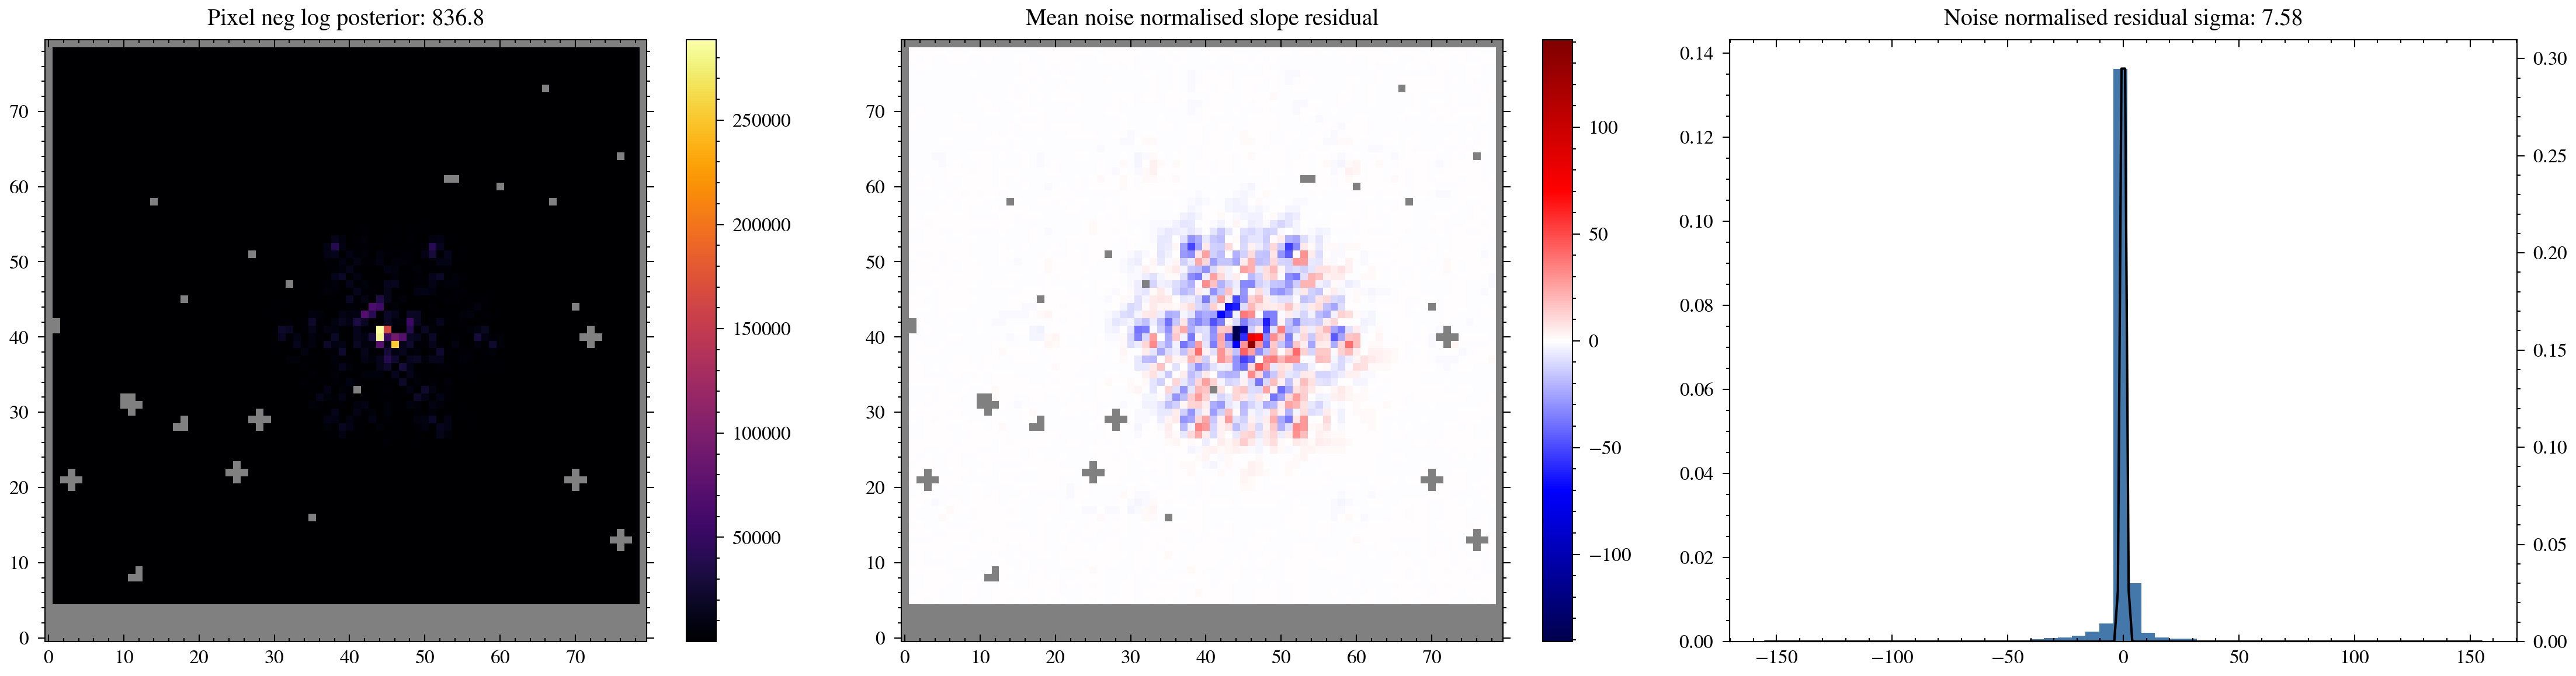

File 04481_001_06_03_5
Star HD-41094
Filter F430M
nints 905
ngroups 20



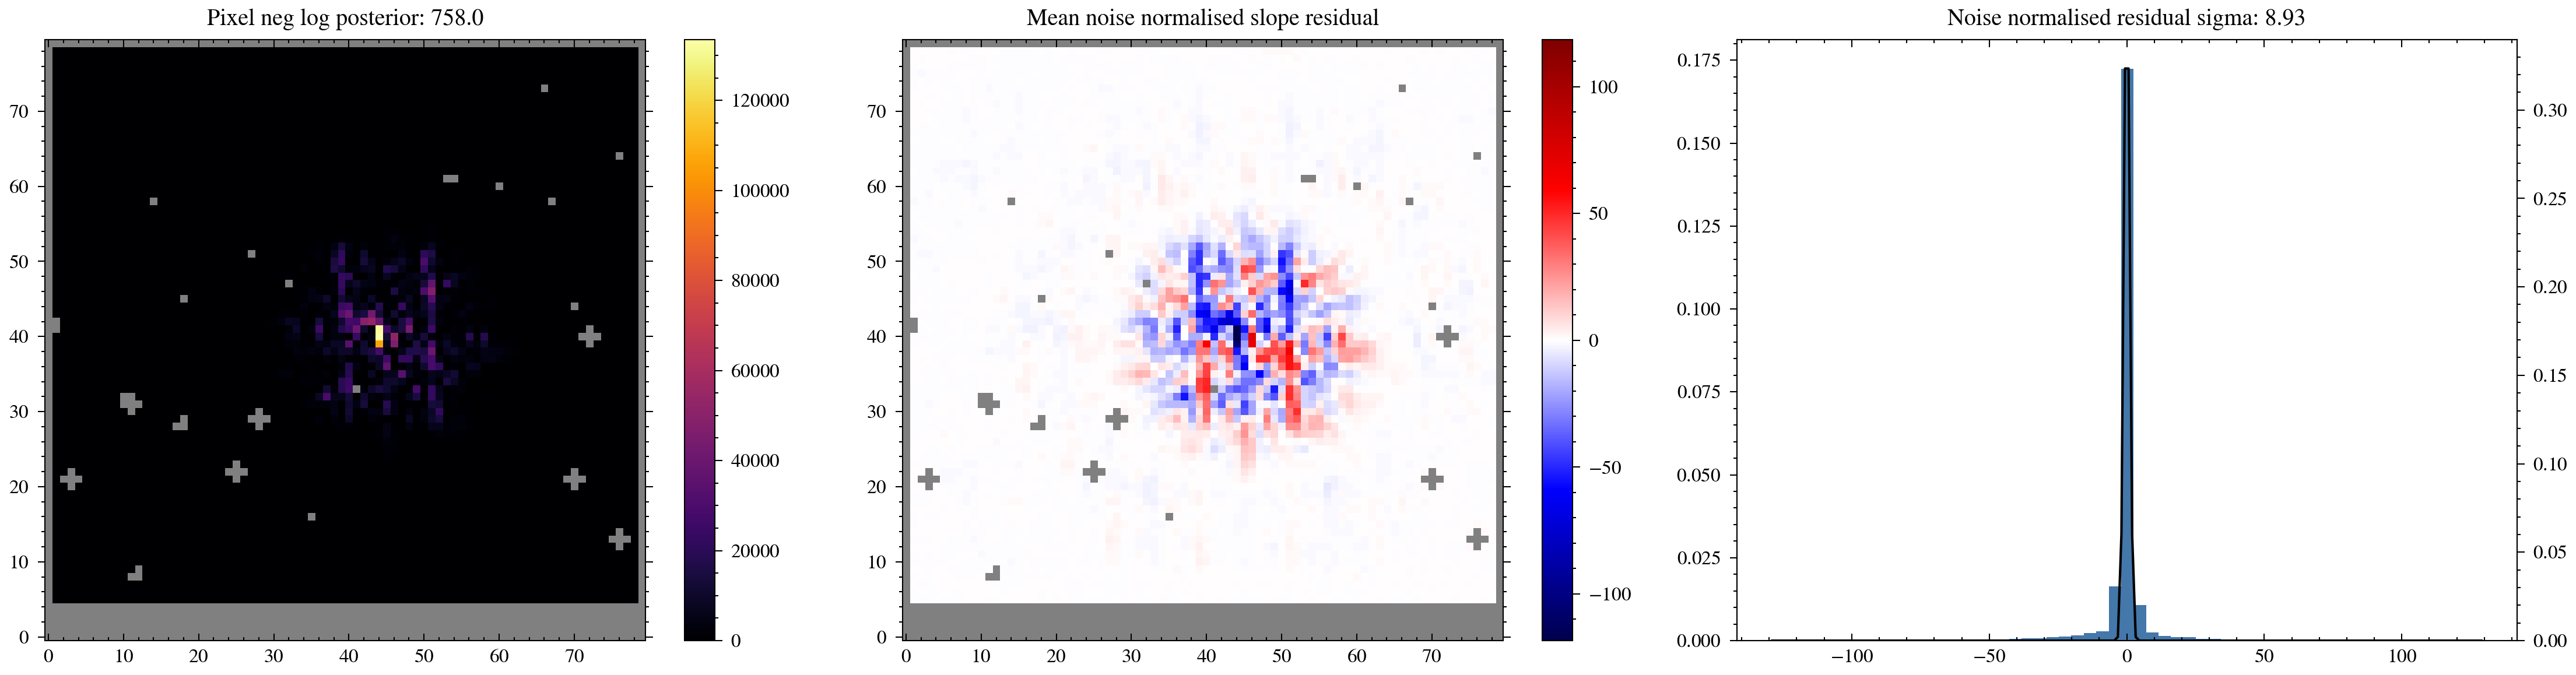

File 04481_001_04_03_5
Star HD-41094
Filter F380M
nints 1060
ngroups 11



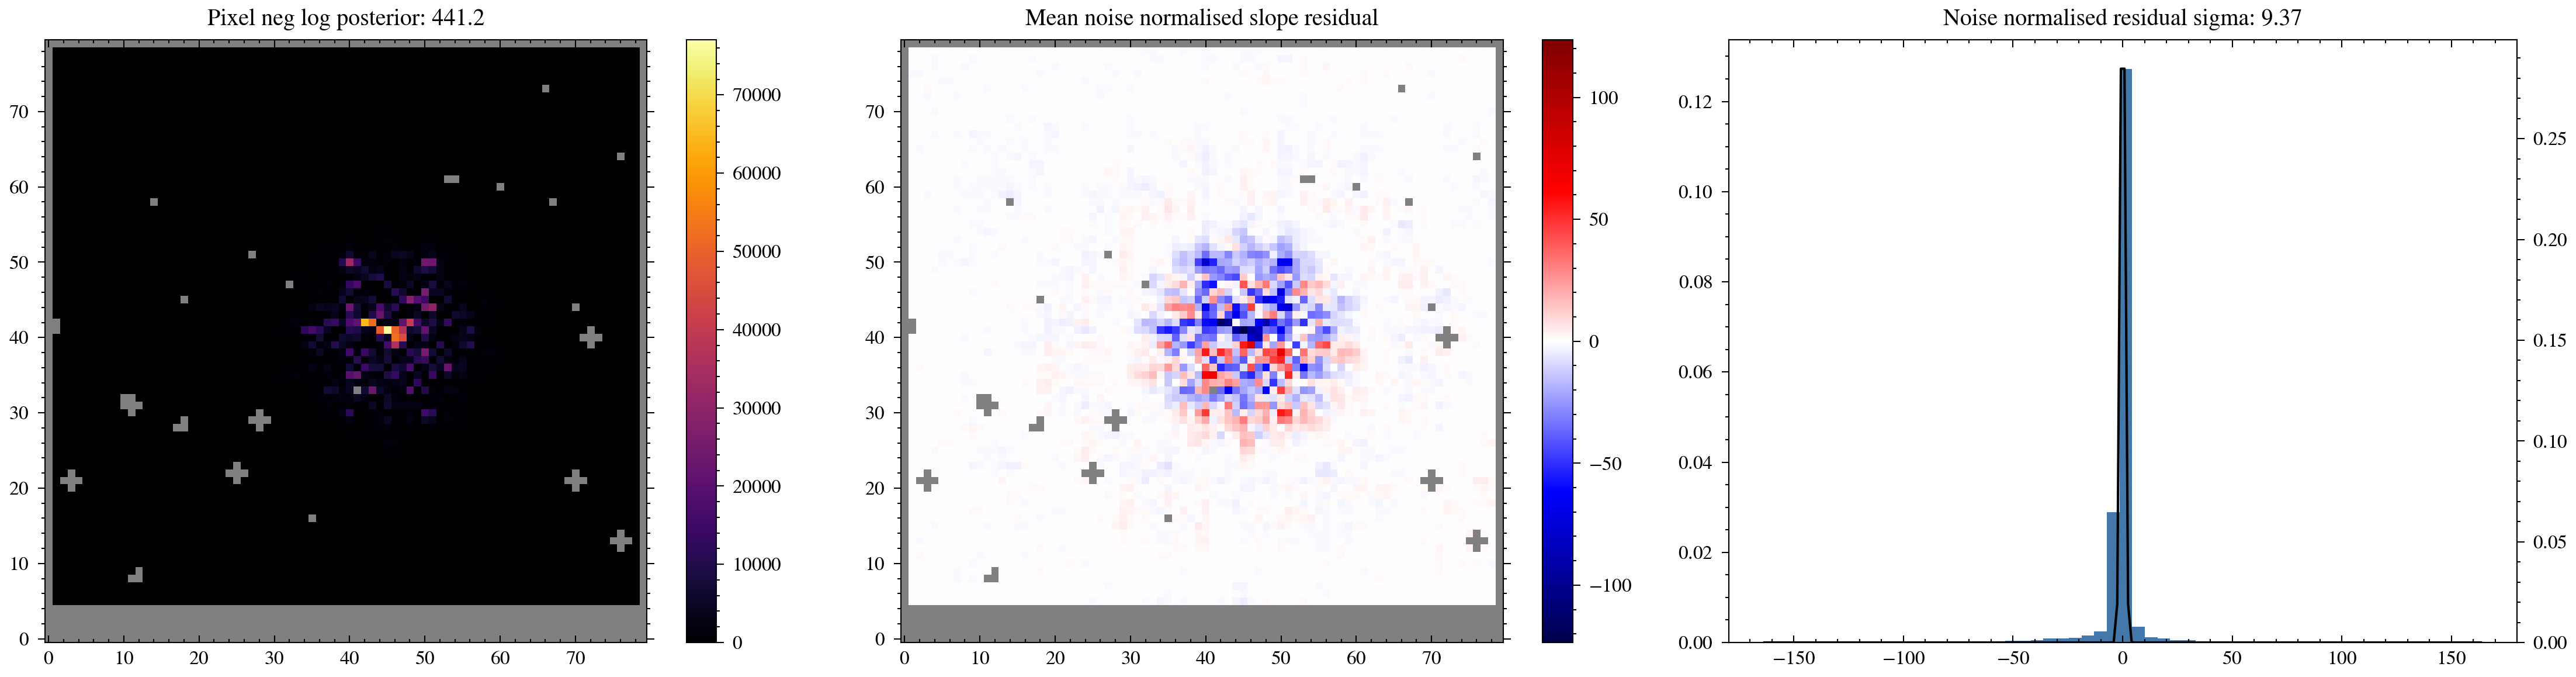

In [13]:
from amigo.plotting import summarise_fit

if plot_flag:
    if save_flag:
        this_save_path = os.path.join(save_path, "init_cal")
        os.mkdir(this_save_path)
    else:
        this_save_path = None
    for exp in cal_exposures:
        exp.print_summary()
        # try:
        summarise_fit(model, exp, save_path=this_save_path)
        # except Exception as e:
            # print(f"Plotting failed: {e}")
            # pass

Now the validator exposures.

In [14]:
if plot_flag:
    if val_flag:
        if save_flag:
            this_save_path = os.path.join(save_path, "init_val")
            os.mkdir(this_save_path)
        else:
            this_save_path = None
        for exp in val_exposures:
            print(exp.program, exp.filter, exp.star, exp.ngroups, exp.nints, exp.filename)
            summarise_fit(model, exp, save_path=this_save_path)

Finally, the flats and darks.

In [15]:
if plot_flag:
    if flat_flag:
        if save_flag:
            this_save_path = os.path.join(save_path, "init_flat")
            os.mkdir(this_save_path)
        else:
            this_save_path = None
        for exp in flat_exposures:
            print(exp.program, exp.filter, exp.star, exp.ngroups, exp.nints)
            summarise_fit(model, exp, save_path=this_save_path)

# Optimisation

## Setup
For the neural network training we want to use a custom learning rate warmup and a temperature decay, so we will have to modify a lot of the statistical functions of amigo to be able to handle this

In [16]:
from retrain_fns import (
    loss_fn,
    args_fn,
    looper_fn,
    # grads_fn,
    aux_fn,
    ff_reg,
    nl_reg,
    temp_decay,
    cosine_warmup,
)

from retrain_fns import get_warmup, get_temperature


def norm_fn(model_params, args):
    """
    Normalisation function.
    """
    # flat field
    if hasattr(model_params, "FF"):
        FF = model_params.FF
        FF -= np.median(FF) - 1.0
        FF = FF.at[badpix].set(1.0)
        model_params = model_params.set("FF", FF)

    # non linearity
    if hasattr(model_params, "non_linearity"):
        non_lin = model_params.non_linearity.at[:, badpix].set(0)
        model_params = model_params.set("non_linearity", non_lin)

    # spectra clipping
    if hasattr(model_params, "spectra"):
        spectra = model_params.spectra
        clip_fn = lambda x: np.clip(x, a_min=-0.8, a_max=0.8)
        spectra = jax.tree.map(clip_fn, spectra)
        model_params = model_params.set("spectra", spectra)

    return model_params, args


def grads_fn(model, grads, args):

    # Get the parameters
    grad_params = grads.params
    
    if "nn_weights" not in grad_params.keys():
        return grads, args

    # Get the key and update args with new key
    key, subkey = jr.split(args["key"], 2)
    args["key"] = subkey

    # Adds a temperature to the NN gradients
    values = grad_params["nn_weights"]
    temp = get_temperature(args)
    rand_vals = temp * jr.normal(key, values.shape)
    values += rand_vals

    # Add the learning rate warm-up (we also warm up the temperature here)
    values *= args["max_lr"] * get_warmup(args)

    # Increment the t parameter
    args["t"] += 1.0 / args["n_batch"]

    grad_params["nn_weights"] = values
    grads = grads.set("params", grad_params)

    return grads, args

# REGULARISATION
reg_dict = {
    "FF": (1.0, ff_reg),
    "NL": (1.0, nl_reg),
}

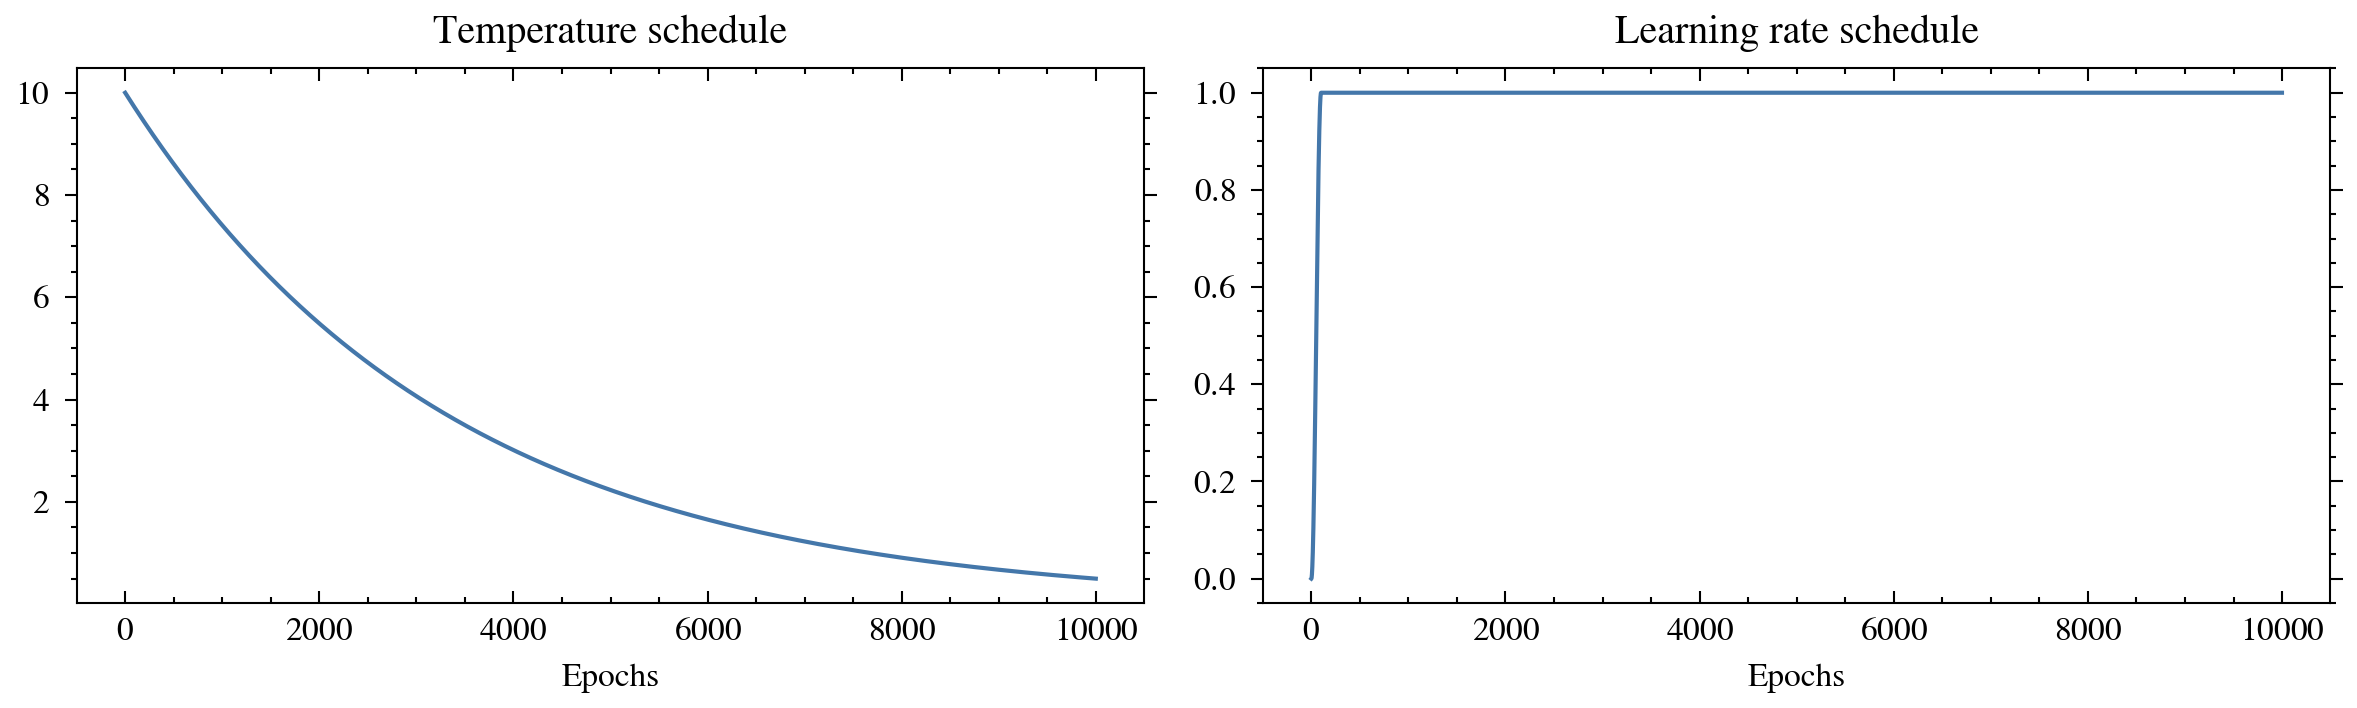

In [17]:
n_batch = len(nn_batches)

# WARM UP
max_lr = 1.  # Learning rate after warm up
t0 = 0  # Warm-up start
n_max = 100  # Warm-up end

# TEMPERATURE DECAY
T0 = 1e1  # Initial temperature
# T0 = 1e-1  # Initial temperature
# T0 = 1e-6  # Initial temperature
decay = 0.0003  # Decay rate of the temperature

args = {
    "n_batch": np.array(n_batch, float),  # Number of batches
    "key": jr.key(0),  # RNG Key
    "t": np.array(0.0),  # Initial time step
    "T0": np.array(T0),  # Initial temperature
    "k": np.array(decay),  # Decay rate
    "t0": np.array(t0),  # Warm-up start
    "n_max": np.array(n_max),  # Warm-up end point
    "l2": np.array(0.0),
    "max_lr": np.array(max_lr),  # Learning rate after warm up
    "reg_dict": reg_dict,
}

ts = np.arange(epochs)
temps = temp_decay(args["T0"], args["k"], ts)
lrs = cosine_warmup(ts, args["t0"], args["n_max"])
l2s = 0 * cosine_warmup(ts, 0, 1000)
args = {**args, **{"l2_schedule": l2s}}


fig, ax = plt.subplots(1, 2, figsize=(8, 2.5))
ax[0].set(title="Temperature schedule", xlabel="Epochs")
ax[0].plot(ts, temps, label="Temperature")
ax[1].set(title="Learning rate schedule", xlabel="Epochs")
ax[1].plot(ts, lrs, label="Learning rate")

plt.tight_layout()
if save_flag:
    plt.savefig(os.path.join(save_path, "schedules.png"), dpi=200)
    plt.close()
else:
    plt.show()

Instantiating trainer class and updating fishers.

In [18]:
from amigo.calibration import ValBatchedTrainer, Trainer  # , looper_fn, aux_fn
from dorito.stats import apply_regularisers
from retrain_fns import summarise_fn

# NOTE: This seems to nuke the jitter/SRF gradient??
linear_model = model.set(["psf_upsample", "bleed"], [1, False])

# Trainer class
trainer_class = ValBatchedTrainer if val_flag else Trainer

trainer_class_kwargs = {
    "loss_fn": loss_fn,
    "args_fn": args_fn,
    "grad_fn": grads_fn,
    "norm_fn": norm_fn,
    "summarise_fn": summarise_fn,
    "intermediate_prints": intermediate_prints,
    "save_path": save_path,
    "cache": cache_dir,
}


if val_flag:
    trainer_class_kwargs["aux_fn"] = aux_fn
    trainer_class_kwargs["looper_fn"] = looper_fn
    

trainer = trainer_class(**trainer_class_kwargs)

# TODO should there be all the detector parameters here?
if flat_flag:
    print("Flat exposures")
    trainer = trainer.update_fishers(
        linear_model,
        flat_exposures,
        parameters=["flat_coeffs", "fluxes"],
        recalculate=recalculate_flag,
        overwrite=recalculate_flag,
    )

if val_flag:
    print("Val exposures")
    trainer = trainer.update_fishers(
        linear_model,
        val_exposures,
        batch_size=10,
        parameters=["positions", "aberrations", "fluxes", "spectra"],
        recalculate=recalculate_flag,
        overwrite=recalculate_flag,
    )

if not flat_only:
    print("Batched cal")
    ps = ["aberrations", "defocus"]
    if not static_optics:
        ps += ["distortion", "primary_beam"]
    trainer = trainer.update_fishers(
        linear_model,
        cal_exposures,
        batch_size=10,
        parameters=ps,
        recalculate=recalculate_flag,
        overwrite=recalculate_flag,
    )

    print("Unbatched cal")
    trainer = trainer.update_fishers(
        linear_model,
        cal_exposures,
        parameters=[
            "positions",
            "fluxes",
            "spectra",
            "sigma",  # formerly jitter
            "dark_current",
        ],
        recalculate=recalculate_flag,
        overwrite=recalculate_flag,
    )
    
    if binary_flag:
        print("Binary Exposures")
        trainer = trainer.update_fishers(
            linear_model,
            calbin_exposures,
            parameters=[
                "pas",
                "separations",
                "contrasts",
            ],
            recalculate=recalculate_flag,
            overwrite=recalculate_flag,
        )

Batched cal


  0%|          | 0/3 [00:00<?, ?it/s]

Unbatched cal


  0%|          | 0/3 [00:00<?, ?it/s]

Training.

In [ ]:
from amigo.fitting import sgd, adam

# Define the optimisers
optimisers = {
    "fluxes": sgd(1e-3, 0),
    "flat_coeffs": sgd(1e-3, 0),
    "positions": sgd(1e-3, 2),
    "aberrations": sgd(1e-4, 5),
    # "pas": sgd(2e-3, 5),
    # "separations": sgd(5e-4, 7),
    # "contrasts": sgd(5e-4, 8),
    # "nn_weights": sgd(0., 10000),  # lr applied with warm up
    "nn_weights": sgd(1e-5, 0),  # lr applied with warm up
    # "defocus": sgd(1e-3, 25),
    "distortion": sgd(1e-4, 30),
    # "dark_current": sgd(2e-3, 35),
    "primary_beam": sgd(2e-5, 40),
    # "sigma": sgd(1e-3, 50),  # start at 50th?
    # "non_linearity": sgd(1e-4, 100),
    # "FF": sgd(2e-5, 150),
    # "spectra": sgd(1e-3, 2000),
    # #
    # "dark_current": sgd(2e-3, 5),
    # "non_linearity": sgd(1e-3, 10),
    # "FF": sgd(1e-3, 20),
}

if not binary_flag:
    bin_ps = ["pas", "separations", "contrasts"]
    optimisers = {key: val for key, val in optimisers.items() if key not in bin_ps}

if not flat_flag:
    flat_ps = ["flat_coeffs"]
    optimisers = {key: val for key, val in optimisers.items() if key not in flat_ps}

if static_optics:
    dyn_ps = ["distortion", "primary_beam"]
    optimisers = {key: val for key, val in optimisers.items() if key not in dyn_ps}
    
        
print(optimisers.keys())
# This seems to fix some recompile issues
def fn(x):
    if isinstance(x, jax.Array):
        if "i" in x.dtype.str:
            return x
        return np.array(x, dtype=float)
    return x
model = jtu.map(fn, model)

if flat_flag:
    batches = {**cal_batch, **flat_batch} if not flat_only else flat_batch
else:
    batches = cal_batch

summarise_kwargs = {
    "val_flag": val_flag,
    "flat_flag": flat_flag,
    "save_flag": save_flag,
    "flat_only": flat_only,
    "static_optics": static_optics,
    "cal_exposures": cal_exposures,
    "val_exposures": val_exposures,
    "flat_exposures": flat_exposures,
    "calpsf_exposures": calpsf_exposures,
    "calbin_exposures": calbin_exposures,
    "badpix": badpix,
    "n_batch": n_batch,
    "optimisers": optimisers,
}

common_trainer_kwargs = {
    "model": model,
    "optimisers": optimisers,
    "epochs": epochs,
    "batches": batches,
    "args": args,
    "summarise_kwargs": summarise_kwargs,
}

if val_flag:
    if "nn_weights" in optimisers.keys():
        common_trainer_kwargs["batched_params"] = ["nn_weights"]
    else:
        common_trainer_kwargs["batched_params"] = []

val_trainer_kwargs = {
    "validators": val_batch,
    "validator_params": ["positions", "fluxes", "aberrations", "spectra"]
    }

trainer_kwargs = {**common_trainer_kwargs, **val_trainer_kwargs} if val_flag else common_trainer_kwargs

# with jax.disable_jit():
result = trainer.train(**trainer_kwargs)

dict_keys(['fluxes', 'positions', 'aberrations', 'nn_weights', 'distortion', 'primary_beam'])


  0%|          | 0/10000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 1,361.26
Compiling Loss function...
Estimated run time: 4 days, 4:58:30


Plotting the results of that fit!

# Saving results

In [ ]:
summarise_fn(result, save_path, **summarise_kwargs)

In [ ]:
# if val_flag:
#     # Unwrapping into cal, val, and flat
#     aux_history = jtu.map(
#         lambda x: np.array(x), result.aux, is_leaf=lambda x: isinstance(x, list)
#     )
    
#     cal, val, flat = [], [], []
#     for (batch_key, exp_key), value in aux_history["loglike"].items():
#         if "cal" in batch_key:
#             cal.append(value)
#         if "val" in batch_key:
#             val.append(value)
#         if "flat" in batch_key:
#             flat.append(value)
#     cal = np.array(cal)
#     val = np.array(val)
#     flat = np.array(flat)

# if val_flag:
#     # Finding BEST STATE from the fit
#     mean_val = np.array(val).mean(0)  # mean loss for validators
#     best = mean_val.min()  # best state is where the validator loss was minimum
#     idx = np.where(mean_val == best)[0][0]
#     test_aux = jtu.map(
#         lambda x: x[: idx + 1], result.aux, is_leaf=lambda x: isinstance(x, list)
#     )
#     print(f"Best: {idx}")
#     print(looper_fn(result.losses, test_aux))

# if save_flag:
#     try:
#         # --- best_state.npy ---
#         # model_params from the epoch with best validation loss,
#         # with nn_weights replaced by the mean across all batches
#         # of that epoch (since nn_weights is a batched parameter,
#         # best_state only contains its value at the final batch)
#         if not type(trainer) == amigo.fitting.Trainer:
#             best_params = result.best_state.params
#             best_params["nn_weights"] = np.array(
#                 result.best_batch["nn_weights"]
#             ).mean(0)
#             np.save(
#                 os.path.join(save_path, "best_state.npy"),
#                 best_params,
#                 allow_pickle=True,
#             )

#         # --- final_state.npy ---
#         # model_params from the final epoch of training,
#         # independent of validation loss
#         final_params = result.state.params
#         final_params["nn_weights"] = np.array(
#             result.history["nn_weights"]  # all batches of final epoch
#         )[-n_batch:].mean(0)
#         np.save(
#             os.path.join(save_path, "final_state.npy"),
#             final_params,
#             allow_pickle=True,
#         )

#     except Exception as e:
#         print(f"Saving failed: {e}")

# Plotting results

## Loss curves

In [ ]:
# start, stop = 50, -1

# if val_flag:
#     #
#     # epochs = cal.shape[-1]
#     # start, stop = 500, -1
    
#     if start >= cal.shape[-1]:
#         start = 1
    
#     if stop < 0:
#         stop = cal.shape[-1] + stop
#     xs = np.arange(start, stop)
    
#     # print(np.array(cal).mean(0)[xs].shape)
    
#     plt.figure(figsize=(18, 4))
#     ax = plt.subplot(1, 3, 1)
#     plt.plot(xs, np.array(cal).mean(0)[xs])
#     ax.set(title="Calibrators", xlabel="Epochs", ylabel="Loss")
    
#     ax = plt.subplot(1, 3, 2)
#     ax.set(title="Validators", xlabel="Epochs", ylabel="Loss")
#     if val_flag:
#         plt.plot(xs, np.array(val).mean(0)[xs])
    
#     ax = plt.subplot(1, 3, 3)
#     ax.set(title="Flat", xlabel="Epochs", ylabel="Loss")
#     if flat_flag:
#         plt.plot(xs, np.array(flat).mean(0)[xs])
    
#     plt.tight_layout()
#     if save_flag:
#         plt.savefig(os.path.join(save_path, "mean_losses.png"), dpi=200)
#     plt.show()
    
#     ###
    
#     plt.figure(figsize=(18, 4))
#     ax = plt.subplot(1, 3, 1)
#     ax.set(title="Calibrators", xlabel="Epochs", ylabel="Loss")
#     [plt.plot(xs, ys[xs]) for ys in cal]
    
#     ax = plt.subplot(1, 3, 2)
#     if val_flag:
#         ax.set(title="Validators", xlabel="Epochs", ylabel="Loss")
#     [plt.plot(xs, ys[xs]) for ys in val]
    
#     ax = plt.subplot(1, 3, 3)
#     ax.set(title="Flat", xlabel="Epochs", ylabel="Loss")
#     if flat_flag:
#         [plt.plot(xs, ys[xs]) for ys in flat]
    
#     plt.tight_layout()
#     if save_flag:
#         plt.savefig(os.path.join(save_path, "all_losses.png"), dpi=200)
#     plt.show()

# else:
#     amigo.plotting.plot_losses(list(result.losses.values())[0], start=start, save_path=save_path)
    

## Residuals and parameter curves

In [ ]:
# amigo.plotting.plot(result.history, save_path=save_path)

# exposures_lists = [cal_exposures]
# exp_types = ["cal"]
# if val_flag:
#     exp_types += ["val"]
#     exposures_lists += [val_exposures]
# if flat_flag:
#     exp_types += ["flat"]
#     exposures_lists += [flat_exposures]
    
# for exp_type, exps in zip(exp_types, exposures_lists):
#     print(5*"\n")
#     print(exp_type)
#     if flat_only and exp_type != "flat":
#         continue
#     if save_path is not None:
#         this_save_path = os.path.join(save_path, exp_type)
#         os.mkdir(this_save_path)
#     else:
#         this_save_path = None
#     for exp in exps:
#         exp.print_summary()
#         amigo.plotting.summarise_fit(result.model, exp, save_path=this_save_path)

## Pixel sensitivity and non-linearity

In [ ]:
# inferno_r = get_cmap("inferno_r")

# badpix_bool = badpix.astype(bool)

# FF = result.model.FF.at[badpix_bool].set(np.nan)
# non_lin = result.model.non_linearity[0].at[badpix_bool].set(np.nan)

# ff_xs = np.linspace(np.nanmin(FF), np.nanmax(FF), 100) - 1
# ff_l2 = np.exp(-((ff_xs / 0.035) ** 2))

# med_nl = np.nanmedian(non_lin)
# nl_xs = np.linspace(np.nanmin(non_lin), np.nanmax(non_lin), 100)
# nl_l2 = np.exp(-(((nl_xs - med_nl) / 0.025) ** 2))


# fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# ax1, ax2, ax3, ax4 = axes.flatten()

# # Pixel sensitivity
# ax1.set_title("Sensitivity (FF)")
# im1 = ax1.imshow(FF, seismic, norm=mpl.colors.CenteredNorm(1))
# fig.colorbar(im1, ax=ax1)

# # Linear (imshow)
# ax2.set_title("Non-linearity")
# im2 = ax2.imshow(non_lin, inferno_r, vmax=None)
# fig.colorbar(im2, ax=ax2)

# # FF histogram
# ax3.set_title("FF")
# ax3.hist(FF[::2].flatten(), bins=100, density=True)
# ax3.hist(FF[1::2].flatten(), bins=100, alpha=0.75, density=True)
# ax3.plot(ff_xs + 1, 25 * ff_l2, label="L2", c="k")

# # Linear histogram
# ax4.set_title("non-linearity")
# ax4.hist(non_lin[::2].flatten(), bins=100)
# ax4.hist(non_lin[1::2].flatten(), bins=100, alpha=0.75)
# ax4.plot(nl_xs, 150 * nl_l2, label="L2", c="k")

# fig.tight_layout()
# if save_flag:
#     plt.savefig(os.path.join(save_path, "pixels.png"), dpi=300)
# plt.show()

## Wavefront

In [ ]:
# optics = result.model.optics
# pupil_mask = result.model.optics.pupil_mask

# rms = lambda x: np.sqrt(np.nanmean(np.square(x)))

# if "aberrations" in optimisers.keys():
#     for prog in ["4481", "8330", "1093", "1843", "1242"]:
#         print(prog)
#         cal_aberrations = {key: val for key, val in result.state.aberrations.items() if prog in key}  # NOTE USE ALL 
        
#         fig, axes = plt.subplots(2, 3, figsize=(12, 6))
#         for i, key in enumerate(cal_aberrations):
        
#             coeffs = result.model.aberrations[key]
#             full_abb = pupil_mask.set("abb_coeffs", coeffs).calc_aberrations()
#             flat_abb = pupil_mask.set("abb_coeffs", coeffs.at[:, :3].set(0)).calc_aberrations()
        
#             mask = pupil_mask.calc_mask(optics.wf_npixels, optics.diameter)
        
#             full_abb = np.where(mask < 1.0, np.nan, 1e9 * full_abb)
#             flat_abb = np.where(mask < 1.0, np.nan, 1e9 * flat_abb)
        
#             full_abb -= np.nanmean(full_abb)
#             flat_abb -= np.nanmean(flat_abb)
        
#             ax_top = axes[0, i]
#             ax_bot = axes[1, i]
        
#             v = np.nanmax(np.abs(full_abb))
#             ax_top.set_title(f"{key} — Full OPD (RMS: {rms(full_abb):.2f} nm)")
#             im_top = ax_top.imshow(full_abb, cmap=seismic, vmin=-v, vmax=v)
#             fig.colorbar(im_top, ax=ax_top, label="OPD (nm)")
        
#             v = np.nanmax(np.abs(flat_abb))
#             ax_bot.set_title(f"{key} — FLAT OPD (RMS: {rms(flat_abb):.2f} nm)")
#             im_bot = ax_bot.imshow(flat_abb, cmap=seismic, vmin=-v, vmax=v)
#             fig.colorbar(im_bot, ax=ax_bot, label="OPD (nm)")
        
#         fig.tight_layout()
#         if save_flag:
#             plt.savefig(os.path.join(save_path, f"wavefront_{prog}.png"), dpi=300)
#             plt.close()
#         else:
#             plt.show()

## Pupil and beam

In [ ]:
# null_pupil_mask = model.optics.pupil_mask.multiply("primary_beam", 0.0).multiply("distortion", 0.0)
# null_mask = null_pupil_mask.calc_mask(optics.wf_npixels, optics.diameter)

# pupil_mask = result.model.optics.pupil_mask
# mask = pupil_mask.calc_mask(optics.wf_npixels, optics.diameter)

# fig, ax = plt.subplots(figsize=(3, 2))

# ax.set_title("Pupil & Beam Distortions")
# im = ax.imshow(mask - null_mask, cmap="berlin", norm=mpl.colors.CenteredNorm())
# fig.colorbar(im, ax=ax)

# fig.tight_layout()
# if save_flag:
#     plt.savefig(os.path.join(save_path, "pupil_beam.png"), dpi=300)
#     plt.close()
# else:
#     plt.show()

## Slope plots

In [ ]:
# # Create the cal exposure dictionaries
# cal_dict = {}
# for exp in calpsf_exposures:
#     if exp.filter not in cal_dict:
#         cal_dict[exp.filter] = []
#     cal_dict[exp.filter].append(exp)

# # Create the val exposure dictionaries
# val_dict = {}
# for exp in val_exposures:
#     if exp.filter not in val_dict:
#         val_dict[exp.filter] = []
#     val_dict[exp.filter].append(exp)

In [ ]:
# from amigo.misc import convert_adjacent_to_true

# if save_flag:
#     this_save_path = os.path.join(save_path, "slope_res")
#     os.mkdir(this_save_path)

# exp_types = ["cal", "val"] if val_flag else ["cal"]
# exp_dicts = [cal_dict, val_dict] if val_flag else [cal_dict]

# for typ, dic in zip(exp_types, exp_dicts):
#     for idx, (filt, _) in enumerate(dic.items()):
#         n = 2
#         k = 2 * n + 1
    
#         for exp in dic[filt]:

#             print(exp)
    
#             slopes = exp(result.model)
#             im = slopes.sum(0)
#             peak_pix = im == np.nanmax(im)
#             peak_map = convert_adjacent_to_true(peak_pix, corners=True, n=n)
    
#             ######### plotting #########
#             max_loc = np.argwhere(peak_pix)[0][::-1]
#             square = mpl.patches.Rectangle(max_loc - np.array([2.5, 2.5]), 5, 5, color="r", fill=False)
    
#             fig, ax = plt.subplots(figsize=(3, 2))
#             c = ax.imshow(im, "cividis", norm=mpl.colors.PowerNorm(0.5))
#             ax.add_patch(square)
#             ax.set(title=f"Cropping: {filt}")
#             ax.axis("off")
#             fig.colorbar(c, ax=ax, label="Counts")
#             if save_flag:
#                 plt.savefig(os.path.join(this_save_path, f"{typ}_crop_{filt}.png"), dpi=300)
#                 plt.close()
#             else:
#                 plt.show()
#             ############################
    
#             ind = np.where(peak_map)
#             model_slopes = slopes[:, *ind].reshape(-1, k, k)
#             data_slopes = exp.slopes[:, *ind].reshape(-1, k, k)
#             data_std = exp.variance[:, *ind].reshape(-1, k, k) ** 0.5
    
#             xs = np.arange(len(slopes))
    
#             fig, axes = plt.subplots(k, k, figsize=(3 * k, 3 * k), sharex="col")
#             # fig.suptitle(filt)
    
#             for i in range(k):
#                 for j in range(k):
#                     ax = axes[i, j]
    
#                     if i == k - 1:
#                         ax.set_xlabel("Slope Index")
#                     else:
#                         ax.tick_params(labelbottom=False)
#                     if j == 0:
#                         ax.set_ylabel("Slope (e- / group)")
    
#                     ax.errorbar(
#                         xs, data_slopes[:, i, j], yerr=data_std[:, i, j],
#                         marker='o', capsize=5, label="Data",
#                     )
#                     ax.errorbar(
#                         xs, model_slopes[:, i, j],
#                         marker='x', capsize=5, label="Model"
#                     )
#                     ax.legend()
    
#             # fig.tight_layout()
#             if save_flag:
#                 plt.savefig(os.path.join(this_save_path, f"{typ}_slope_{filt}.png"), dpi=300)
#                 plt.close()
#             else:
#                 plt.show()


In [ ]:
# if not type(trainer) == amigo.fitting.Trainer:
#     nn = result.best_state.params["nn_weights"]
#     nnf = result.state.params["nn_weights"]
#     # nni = model.nn_weights
#     nnh = np.array(result.history["nn_weights"][-n_batch:])
#     nnhm = nnh.mean(0)
#     nnh0 = nnh[0]
#     nnh1 = nnh[1]
    
#     print(nn.shape)
#     nbins = 300
#     # plt.hist(nn, bins=nbins, alpha=0.7, label="best_state")
#     # plt.hist(nnf, bins=nbins, alpha=0.7, label="state")
#     # plt.hist(nnhm, bins=nbins, alpha=0.7, label="history_mean")
#     plt.hist(nnh0, bins=nbins, alpha=0.7, label="history[0]")
#     plt.hist(nnh1, bins=nbins, alpha=0.7, label="history[1]")
#     # plt.hist(nni, bins=nbins, alpha=0.7, label="initial")
#     plt.xlim(-1, 1)
#     plt.legend()
#     plt.show()